# Milestone 2 Polluter Script - Copy for Sampling

- This script is copied from Milestone 1 to generate a sample of 5000 cases for Milestone 2

In [1]:
import pandas as pd
import pm4py
import random
import numpy as np
from pm4py.objects.log.util import sampling

In [2]:
log = pm4py.read_xes("../data/BPI Challenge 2017.xes.gz")

c:\Users\thien\Downloads\Process Mining\ProM-Assignment-Group-C\.venv\Lib\site-packages\pm4py\utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
c:\Users\thien\Downloads\Process Mining\ProM-Assignment-Group-C\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 31509/31509 [01:30<00:00, 349.29it/s]


## Random Sampling

In [5]:
type(log)

pm4py.objects.log.obj.EventLog

In [6]:
no_traces = 5000
log_clean_sample = sampling.sample_log(log, no_traces)
print("Number of traces (sampled clean log):", len(log_clean_sample))

Number of traces (sampled clean log): 5000


In [7]:
pm4py.write_xes(log_clean_sample, "../data/samples/clean_sample.xes.gz")

exporting log, completed traces :: 100%|██████████| 5000/5000 [00:11<00:00, 435.24it/s]


In [8]:
log = pm4py.read_xes("../data/samples/clean_sample.xes.gz")
df = pm4py.convert_to_dataframe(log)

parsing log, completed traces :: 100%|██████████| 5000/5000 [00:11<00:00, 431.60it/s]


## Pollution Script

### 1. Unanchored Events

Coded by: Jonas

In [10]:
df_unanchored = df.copy()

# simulate different data sources (for unique values of EventOrigin)
mask_app = df_unanchored["EventOrigin"] == "Application"
mask_offer = df_unanchored["EventOrigin"] == "Offer"

# convert timestamp objects into strings
df_unanchored["time:timestamp"] = df_unanchored["time:timestamp"].astype("string")

# change the format of timestamp for all rows of a simulated data source
    # format: dd.mm.YYYY HH:MM:SS
df_unanchored.loc[mask_app, "time:timestamp"] = (
    pd.to_datetime(df_unanchored.loc[mask_app, "time:timestamp"], errors="coerce")
    .dt.strftime("%d.%m.%Y %H:%M:%S")
)

# format: YYYY-mm-dd'T'HH:MM:SS:MS'Z'
df_unanchored.loc[mask_offer, "time:timestamp"] = (
    pd.to_datetime(df_unanchored.loc[mask_offer, "time:timestamp"], errors="coerce")
    .dt.strftime("%Y-%m-%dT%H:%M:%S.%fZ")
)

In [11]:
# output to show heterogenous timestamp formats of different simulated data sources (EventOrigin)
for origin in ["Application", "Workflow", "Offer"]:
    print("\n", origin)
    print(
        df_unanchored[df_unanchored["EventOrigin"] == origin]
        .sort_values("time:timestamp")
        .head(5)[["EventOrigin", "time:timestamp"]]
    )


 Application
        EventOrigin       time:timestamp
189442  Application  01.01.2016 11:19:38
189443  Application  01.01.2016 11:19:38
189447  Application  01.01.2016 11:20:37
42184   Application  01.01.2016 13:00:04
42185   Application  01.01.2016 13:00:04

 Workflow
       EventOrigin                    time:timestamp
189444    Workflow  2016-01-01 11:19:38.914000+00:00
189445    Workflow  2016-01-01 11:20:37.391000+00:00
189446    Workflow  2016-01-01 11:20:37.409000+00:00
42186     Workflow  2016-01-01 13:00:04.737000+00:00
42187     Workflow  2016-01-01 13:01:44.651000+00:00

 Offer
      EventOrigin               time:timestamp
72244       Offer  2016-01-02T09:17:05.720000Z
72245       Offer  2016-01-02T09:17:08.762000Z
72246       Offer  2016-01-02T09:19:21.330000Z
72251       Offer  2016-01-02T09:21:26.034000Z
72252       Offer  2016-01-02T09:21:42.022000Z


In [12]:
#check how many events per time format
s = df_unanchored["time:timestamp"].astype(str).str.strip()

iso_mask = s.str.match(r"^\d{4}-\d{2}-\d{2}", na=False)
eu_mask = s.str.match(r"^\d{1,2}\.\d{1,2}\.\d{4}", na=False)
us_mask = s.str.match(r"^\d{1,2}/\d{1,2}/\d{4}", na=False)
utc_mask = s.str.match(r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d+Z$", na=False)

print("ISO:", iso_mask.sum())
print("European:", eu_mask.sum())
print("US-like:", us_mask.sum())
print("UTC:", utc_mask.sum())
print("unknown:", (~(iso_mask | eu_mask | us_mask)).sum())

ISO: 152388
European: 37867
US-like: 0
UTC: 30926
unknown: 79


In [13]:
df_unanchored.to_csv("../data/samples/unanchored_events_sample.csv.gz", index=False, sep=";", compression="gzip")

### 2. Polluted Labels
Coded by: Felix

In [33]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [34]:
def pollute_labels(df, rate = 0.001):
    df = df.copy()
    n = int(len(df) * rate)
    indices = np.random.choice(df.index, n, replace=False)

    for index in indices:
        activity = df.loc[index, "concept:name"]
        case_id = df.loc[index, "case:concept:name"]
        df.loc[index, "concept:name"] = f"{activity} - Incident No. {case_id}"

    return df

### 3. Distorted Labels
Coded by: Felix

In [35]:
df["concept:name"].unique()

<StringArray>
[    'A_Create Application',              'A_Submitted',
           'W_Handle leads',   'W_Complete application',
                'A_Concept',               'A_Accepted',
           'O_Create Offer',                'O_Created',
 'O_Sent (mail and online)',      'W_Call after offers',
               'A_Complete',   'W_Validate application',
             'A_Validating',               'O_Returned',
  'W_Call incomplete files',             'A_Incomplete',
               'O_Accepted',                'A_Pending',
              'O_Cancelled',     'O_Sent (online only)',
              'A_Cancelled',                 'A_Denied',
                'O_Refused', 'W_Assess potential fraud',
  'W_Shortened completion ']
Length: 25, dtype: str

In [36]:
def distort_activity_label(label):
    replacements = {
        "application": "appl.",
        "Application": "App.",
        "offers": "ofrs.",
        "Offer": "Off.",
        "incomplete": "incompl.",
        "Incomplete": "Incompl.",
        "files": "docs.",
        "leads": "lds.",
        "Handle": "Hndl.",
        "Validate": "Valid.",
        "Validating": "Valid.",
        "Complete": "Comp.",
        "Created": "Crtd.",
        "Create": "Crt.",
        "Accepted": "Acc.",
        "Cancelled": "Canc.",
        "Submitted": "Subm.",
        "Pending": "Pend.",
        "Denied": "Den.",
        "Refused": "Ref.",
        "Returned": "Ret.",
        "potential": "pot.",
        "fraud": "frd.",
        "Shortened": "Short.",
        "completion": "compl.",
        "Personal": "Pers.",
        "Loan": "Ln.",
        "collection": "coll.",
        "online": "onl.",
        "mail": "email"
    }

    distorted = str(label)

    for original, replacement in replacements.items():
        if original in distorted:
            return distorted.replace(original, replacement, 1)

    return distorted + "."

In [37]:
def pollute_distorted_labels(
    df,
    activity_column="concept:name",
    rate=0.05,
    pollution_column="pollution_type"
):
    df = df.copy()

    if pollution_column not in df.columns:
        df[pollution_column] = None

    n = int(len(df) * rate)
    indices = np.random.choice(df.index, n, replace=False)

    for index in indices:
        original_label = df.loc[index, activity_column]

        if pd.notna(original_label):
            distorted_label = distort_activity_label(original_label)

            df.loc[index, activity_column] = distorted_label
            df.loc[index, pollution_column] = "distorted_label"

    return df

### 4. Synonymous Labels
Coded by: Thien

In [38]:
SYNONYMS = {
    "W_Complete application": ["W_Finish application", "W_Finalize application"]
}

In [39]:
def add_synonymous_labels(df: pd.DataFrame, fraction: float = 0.3) -> pd.DataFrame:
    """Add synonymous labels randomly to a fraction of the occurrences of specified activities"""
    df = df.copy()
    for original, alternatives in SYNONYMS.items():
        original_rows = df[df["concept:name"] == original]

        if original_rows.empty:
            print(f"[synonymous_labels] Warning: '{original}' not found in log, skipping.")
            continue

        sampled_idx = original_rows.sample(frac=fraction).index
        mask = (df["concept:name"] == original) & (df.index.isin(sampled_idx))
        df.loc[mask, "concept:name"] = [random.choice(alternatives) for _ in range(mask.sum())]

        print(f"[synonymous_labels] Replaced {mask.sum()} / {len(original_rows)} "
              f"occurrences of '{original}'")

    return df

### 5. Collateral Events
Coded by: Thien

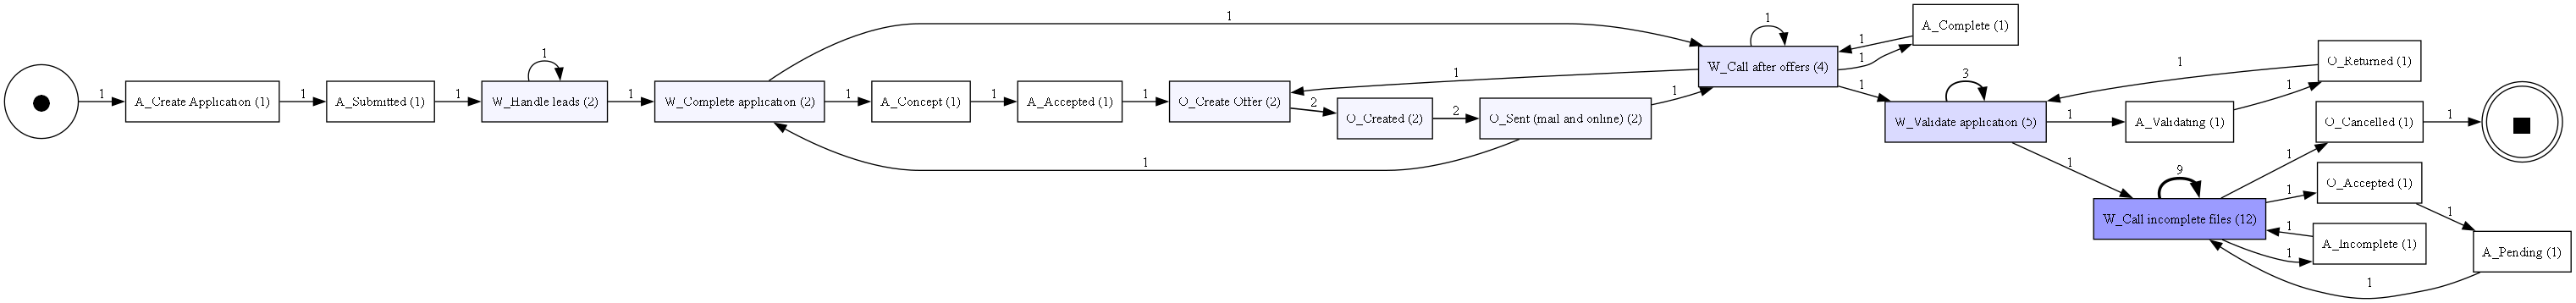

In [40]:
case_list = list(df['case:concept:name'].unique())
dfg, start_activities, end_activities = pm4py.discover_dfg(df[df['case:concept:name'].isin(case_list[:1])])
pm4py.view_dfg(dfg, start_activities, end_activities)

In [41]:
df[df['concept:name']=='W_Complete application'][['Action', 'concept:name', 'lifecycle:transition']].drop_duplicates()

,Action,concept:name,lifecycle:transition
4,Created,W_Complete application,schedule
10,Deleted,W_Complete application,withdraw
44,Obtained,W_Complete application,start
50,Deleted,W_Complete application,complete
77,Released,W_Complete application,suspend
78,Obtained,W_Complete application,resume
87,Deleted,W_Complete application,ate_abort


In [42]:
df['Action'].value_counts()

Action
statechange    57003
Obtained       40304
Created        35417
Released       34090
Deleted        23520
Name: count, dtype: int64

In [43]:
df['lifecycle:transition'].value_counts()

lifecycle:transition
complete     75381
suspend      34090
schedule     23548
start        20238
resume       20066
ate_abort    13532
withdraw      3479
Name: count, dtype: int64

In [44]:
# Sub-steps that logically make up "W_Complete application" - Action = Obtained, lifecycle:transition = start
COLLATERAL_SUBSTEPS = [
    "W_Precheck application: Applicant Identity",
    "W_Precheck application: Form Completeness",
    "W_Precheck application: Credit History",
]

In [45]:
def add_collateral_events(
    df: pd.DataFrame,
    concept_name: str = "W_Complete application",
    action: str = "Obtained",
    lifecycle_transition: str = "start",
    fraction: float = 0.001
) -> pd.DataFrame:
    """
    Inject collateral sub-steps for a fraction of cases.
    Each injected sub-step inherits all column values from the anchor event
    except 'concept:name', 'time:timestamp', and 'start_timestamp', which
    are updated to reflect the sub-step identity and timing (1 second apart)

    Args:
        df (pd.DataFrame): Event log dataframe
        concept_name (str): Activity name to use as the injection anchor
        action (str): The 'Action' column value of the anchor event
        lifecycle_transition (str): The 'lifecycle:transition' value of the anchor event
        fraction (float): Fraction of eligible cases to inject sub-steps into

    Returns:
        pd.DataFrame: Copy of the dataframe with injected collateral sub-step rows
    """
    df = df.copy()
    new_rows = []

    # Get cases that contain W_Complete application with Obtained/start
    target_cases = df[
        (df["concept:name"] == concept_name) &
        (df["Action"] == action) &
        (df["lifecycle:transition"] == lifecycle_transition)
    ]["case:concept:name"].unique()

    if len(target_cases) == 0:
        print(f"[collateral_events] Warning: No matching anchor events found, returning unchanged df.")
        return df
    n_sampled = max(1, int(len(target_cases) * fraction))
    sampled_cases = random.sample(list(target_cases), n_sampled)

    for case_id in sampled_cases:
        # Find specifically the Obtained/start event
        anchor = df[
            (df["case:concept:name"] == case_id) &
            (df["concept:name"] == concept_name) &
            (df["Action"] == action) &
            (df["lifecycle:transition"] == lifecycle_transition)
        ].iloc[0]

        anchor_time = anchor["time:timestamp"]

        # Inject sub-steps after the start event, 1 second apart
        for i, substep in enumerate(COLLATERAL_SUBSTEPS):
            new_rows.append({
                **anchor.to_dict(),
                "concept:name": substep,
                "time:timestamp": anchor_time + pd.Timedelta(seconds=i + 1),
                "start_timestamp": anchor_time + pd.Timedelta(seconds=i + 1),
            })

    new_df = pd.DataFrame(new_rows)
    return pd.concat([df, new_df]).sort_values(
        ["case:concept:name", "time:timestamp"]
    ).reset_index(drop=True)

### 6. Scattered Cases
Coded by: Thien

In [46]:
df[df['concept:name'].str.contains("valid", case=False)]['concept:name'].value_counts()

concept:name
W_Validate application    32566
A_Validating               6104
Name: count, dtype: int64

In [47]:
def add_scattered_cases(
    df: pd.DataFrame,
    concept_name: str = "valid"
) -> pd.DataFrame:
    """
    Simulate scattered cases by removing all events containing given word
    in concept:name and saving them to a separate CSV (simulating another system)
    Args:
        df (pd.DataFrame): Event log dataframe
        concept_name (str): Keyword to match against 'concept:name' (case-insensitive).
    Returns:
        pd.DataFrame: Copy of the dataframe with matching events removed
    """
    df = df.copy()

    # Find all rows containing the concept name (case-insensitive)
    mask = df["concept:name"].str.contains(concept_name, case=False, na=False)

    if mask.sum() == 0:
        print(f"[scattered_cases] Warning: No events found containing '{concept_name}', returning unchanged df.")
        return df

    # Split into two
    scattered_df = df[mask]
    clean_df = df[~mask]

    # Save the removed events to separate CSV
    scattered_df.to_csv("../data/samples/scattered_events_sample.csv.gz", index=False, compression="gzip")
    print(f"Saved removed event")

    return clean_df

## Run Pollution Scripts

In [48]:
df_polluted = df.copy()
# Scattered Cases
df_polluted = add_scattered_cases(
    df_polluted,
    concept_name="valid"
)
# Distorted Labels
df_polluted = pollute_distorted_labels(
    df_polluted,
    activity_column="concept:name",
    rate=0.05
)
# Polluted Labels
df_polluted = pollute_labels(df_polluted)
# Synonymous Labels
df_polluted = add_synonymous_labels(df_polluted)
# Colletaral events
df_polluted = add_collateral_events(df_polluted)

Saved removed event
[synonymous_labels] Replaced 6701 / 22338 occurrences of 'W_Complete application'


## Export Noised XES

In [52]:
event_log_polluted = pm4py.convert_to_event_log(df_polluted)

In [53]:
pm4py.write_xes(event_log_polluted, "../data/samples/noised_sample.xes.gz")

exporting log, completed traces :: 100%|██████████| 5000/5000 [00:09<00:00, 524.01it/s]
